In [1]:
import pybamm

model = pybamm.lithium_ion.DFN()
parameter_values = pybamm.ParameterValues("Chen2020")  # 5 Ah NMC/Graphite cell


def eps_e_n(x):
    L_n = pybamm.Parameter("Negative electrode thickness [m]")
    a = pybamm.InputParameter("a")
    b = pybamm.InputParameter("b")
    return a + (b - a) * x / L_n


def eps_s_n(x):
    # 95% of the active material volume fraction
    return 0.95 * (1 - eps_e_n(x))


parameter_values.update(
    {
        "Negative electrode porosity": eps_e_n,
        "Negative electrode active material volume fraction": eps_s_n,
        "Current function [A]": 10,  # 2C discharge for 5 Ah cell
    }
)

solver = pybamm.IDAKLUSolver()
sim = pybamm.Simulation(model, parameter_values=parameter_values, solver=solver)
sols = {}
designs = {
    "More porosity near current collector": {"a": 0.35, "b": 0.15},
    "More porosity near separator": {"a": 0.15, "b": 0.35},
    "Constant porosity": {"a": 0.25, "b": 0.25},
}
for name, design in designs.items():
    sols[name] = sim.solve([0, 1800], inputs=design)

pybamm.dynamic_plot(
    list(sols.values()),
    [
        "Voltage [V]",
        "Negative electrode porosity",
        "Negative electrode active material volume fraction",
        "Electrolyte concentration [mol.m-3]",
        "Electrolyte potential [V]",
        "Negative electrode interfacial current density [A.m-2]",
    ],
    labels=sols.keys(),
)

2024-08-28 15:26:41.890 - [WARNING] citations.read_citations(76): Citations could not be read because the 'pybtex' library is not installed. Install 'pybamm[cite]' to enable citation reading.


interactive(children=(FloatSlider(value=0.0, description='t', max=1629.967524837035, step=16.29967524837035), …

In [ ]:
def cycle(c_rate):
    return [
        (
            pybamm.step.c_rate(c_rate, termination="2.5V"),
            pybamm.step.c_rate(0, duration=60*30),
            pybamm.step.c_rate(-c_rate, termination="4.2V"),
            pybamm.step.voltage(4.2, termination="0.05C"),
            pybamm.step.c_rate(0, duration=60*30),
        )
    ]

experiment = []
for c_rate in [1/2, 1, 2]:
    experiment += cycle(c_rate) * 3

experiment = pybamm.Experiment(experiment)
sim = pybamm.Simulation(model, parameter_values=parameter_values, experiment=experiment, solver=solver)

capacities = {}
for name, design in designs.items():
    sol = sim.solve(inputs=design)
    for cycle in sol.cycles:
        step = cycle.steps[0]
        q = step["Discharge capacity [A.h]"].data[-1]
        capacities.setdefault(name, []).append(q)

2024-08-28 15:06:08.151 - [ERROR] callbacks.on_experiment_error(233): Simulation error: idaklu solver failed

[IDAS ERROR]  IDASolve
  At t = 96508.3, , mxstep steps taken before reaching tout.



: 

: 

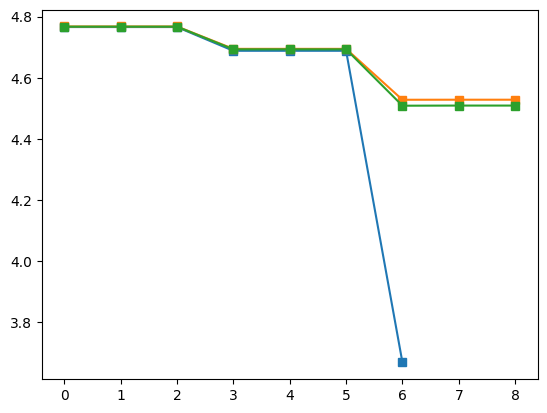

: 

: 

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
for name, q in capacities.items():
    ax.plot(q, "-s", label=name)

: 

: 